=== Algorithmen Vergleich ===
RandomForest: 0.8435754189944135
Logistic Regression: 0.8268156424581006
KNN: 0.7430167597765364

=== Cross Validation ===
Einzelne Scores: [0.74860335 0.82022472 0.83707865 0.79775281 0.83146067]
Durchschnitt: 0.8070240411775783

=== Confusion Matrix ===


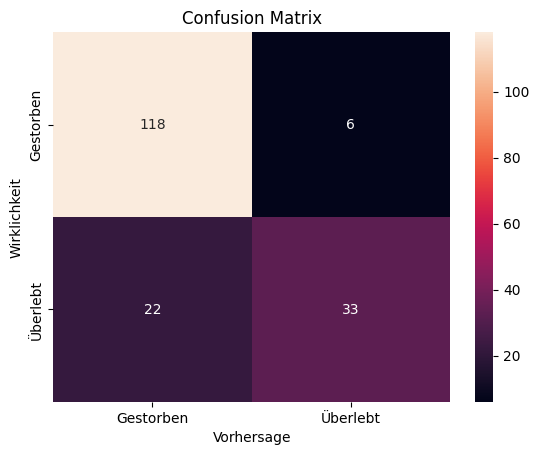


=== Classification Report ===
              precision    recall  f1-score   support

   Gestorben       0.84      0.95      0.89       124
    Überlebt       0.85      0.60      0.70        55

    accuracy                           0.84       179
   macro avg       0.84      0.78      0.80       179
weighted avg       0.84      0.84      0.84       179



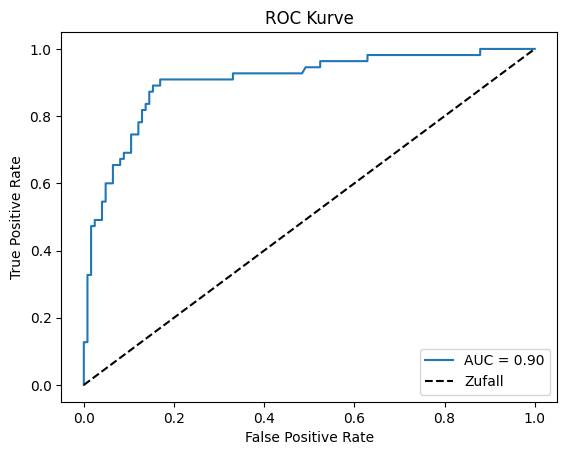

AUC Score: 0.9038856304985338


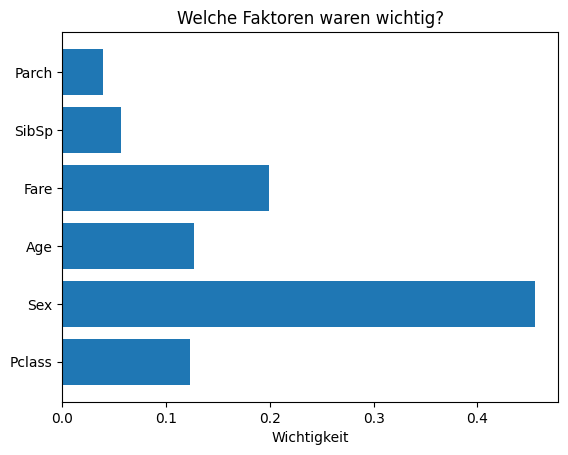


=== Pipeline Genauigkeit ===
0.8268156424581006
Pipeline gespeichert!
Vorhersage: Überlebt!


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix

# Daten laden
df = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")

# Data Cleaning
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# ML Vorbereitung
X = df[["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch"]]
y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Algorithmen vergleichen
print("=== Algorithmen Vergleich ===")
modell_rf = RandomForestClassifier(n_estimators=100, max_depth=5)
modell_rf.fit(X_train, y_train)
print("RandomForest:", modell_rf.score(X_test, y_test))

modell_lr = LogisticRegression()
modell_lr.fit(X_train, y_train)
print("Logistic Regression:", modell_lr.score(X_test, y_test))

modell_knn = KNeighborsClassifier(n_neighbors=5)
modell_knn.fit(X_train, y_train)
print("KNN:", modell_knn.score(X_test, y_test))

# Cross Validation
print("\n=== Cross Validation ===")
scores = cross_val_score(modell_rf, X, y, cv=5)
print("Einzelne Scores:", scores)
print("Durchschnitt:", scores.mean())

# Confusion Matrix
print("\n=== Confusion Matrix ===")
y_pred = modell_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Gestorben", "Überlebt"],
            yticklabels=["Gestorben", "Überlebt"])
plt.title("Confusion Matrix")
plt.ylabel("Wirklichkeit")
plt.xlabel("Vorhersage")
plt.show()

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["Gestorben", "Überlebt"]))

# ROC Kurve
y_prob = modell_rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], "k--", label="Zufall")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Kurve")
plt.legend(loc="lower right")
plt.show()
print("AUC Score:", auc_score)

# Feature Importance
feature_names = ["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch"]
importance = modell_rf.feature_importances_
plt.barh(feature_names, importance)
plt.title("Welche Faktoren waren wichtig?")
plt.xlabel("Wichtigkeit")
plt.show()

# Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("modell", RandomForestClassifier(n_estimators=100, max_depth=5))
])
pipeline.fit(X_train, y_train)
print("\n=== Pipeline Genauigkeit ===")
print(pipeline.score(X_test, y_test))

# Pipeline speichern
joblib.dump(pipeline, "/kaggle/working/titanic_pipeline.pkl")
print("Pipeline gespeichert!")

# Pipeline laden und testen
pipeline_geladen = joblib.load("/kaggle/working/titanic_pipeline.pkl")
neuer_passagier = pd.DataFrame([{
    "Pclass": 1,
    "Sex": 1,
    "Age": 25,
    "Fare": 100,
    "SibSp": 0,
    "Parch": 0
}])
vorhersage = pipeline_geladen.predict(neuer_passagier)
print("Vorhersage:", "Überlebt!" if vorhersage[0] == 1 else "Nicht überlebt!")